In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import zipfile

zip_file = "Training_Batch_Files.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Training_Batch_Files.zip to Training_Batch_Files (2).zip


In [9]:
import os

for root, dirs, files in os.walk("dataset"):
    for file in files:
        print(os.path.join(root, file))

dataset/Training_Batch_Files/cement_strength_08012020_120000.csv
dataset/Training_Batch_Files/cement_strength_08012020_120021.csv
dataset/Training_Batch_Files/cement_strength_08012020_1200.csv


In [10]:
import pandas as pd
import glob

csv_files = glob.glob("dataset/**/*.csv", recursive=True)

print(csv_files)

['dataset/Training_Batch_Files/cement_strength_08012020_120000.csv', 'dataset/Training_Batch_Files/cement_strength_08012020_120021.csv', 'dataset/Training_Batch_Files/cement_strength_08012020_1200.csv']


In [11]:
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

print(df.shape)
df.head()

(3090, 18)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Cement _component_1,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Concrete_compressive _strength,Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture)
0,540.0,0.0,0.0,1040.0,676.0,28.0,79.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,540.0,0.0,0.0,1055.0,676.0,28.0,61.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,332.5,142.5,0.0,932.0,594.0,270.0,40.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,332.5,142.5,0.0,932.0,594.0,365.0,41.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,198.6,132.4,0.0,978.4,825.5,360.0,44.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3090 entries, 0 to 3089
Data columns (total 18 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              2060 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  2060 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             2060 non-null   float64
 3   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   2060 non-null   float64
 4   Fine Aggregate (component 7)(kg in a m^3 mixture)      2060 non-null   float64
 5   Age (day)                                              2060 non-null   float64
 6   Concrete compressive strength(MPa, megapascals)        2060 non-null   float64
 7   Cement _component_1                                    1030 non-null   float64
 8   Blast Furnace Slag _component_2                 

In [13]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Cement _component_1,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Concrete_compressive _strength,Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture)
count,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,972.918932,773.580485,45.662136,35.817961,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961,181.567282,6.204660
std,104.480983,86.258387,63.981461,77.735070,80.156508,63.154570,16.701685,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742,21.354219,5.973841
min,102.000000,0.000000,0.000000,801.000000,594.000000,1.000000,2.330000,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000,121.800000,0.000000
25%,192.000000,0.000000,0.000000,932.000000,730.400000,7.000000,23.700000,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000,164.900000,0.000000
50%,272.900000,22.000000,0.000000,968.000000,779.500000,28.000000,34.445000,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000,185.000000,6.400000
75%,350.000000,143.000000,118.300000,1029.400000,824.000000,56.000000,46.200000,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000,192.000000,10.200000
max,540.000000,359.400000,200.100000,1145.000000,992.600000,365.000000,82.600000,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000,247.000000,32.200000


In [14]:
df.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),1030
Blast Furnace Slag (component 2)(kg in a m^3 mixture),1030
Fly Ash (component 3)(kg in a m^3 mixture),1030
Coarse Aggregate (component 6)(kg in a m^3 mixture),1030
Fine Aggregate (component 7)(kg in a m^3 mixture),1030
Age (day),1030
"Concrete compressive strength(MPa, megapascals)",1030
Cement _component_1,2060
Blast Furnace Slag _component_2,2060
Fly Ash _component_3,2060


In [25]:
print(df.shape)

(3010, 18)


In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 80


In [26]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (3010, 18)


In [34]:
print(df.shape)

(3010, 18)


In [27]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3010
Columns: 18


In [18]:
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) ',
       'Cement _component_1', 'Blast Furnace Slag _component_2',
       'Fly Ash _component_3', 'Water_component_4',
       'Superplasticizer_component_5', 'Coarse Aggregate_component_6',
       'Fine Aggregate_component_7', 'Age_day',
       'Concrete_compressive _strength',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)'],
      dtype='object')

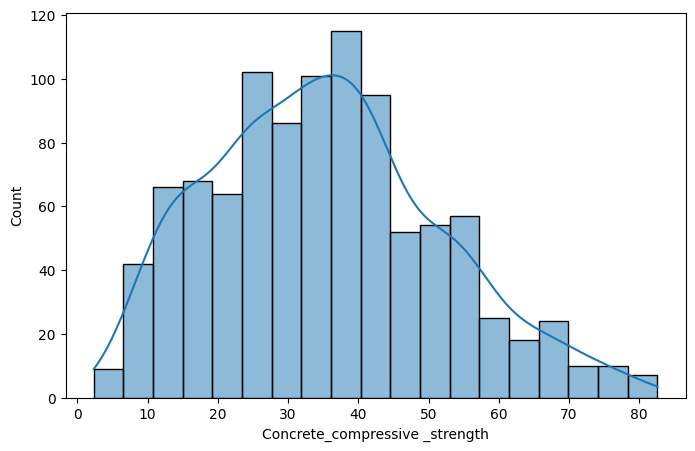

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['Concrete_compressive _strength'],
    kde=True
)

plt.show()

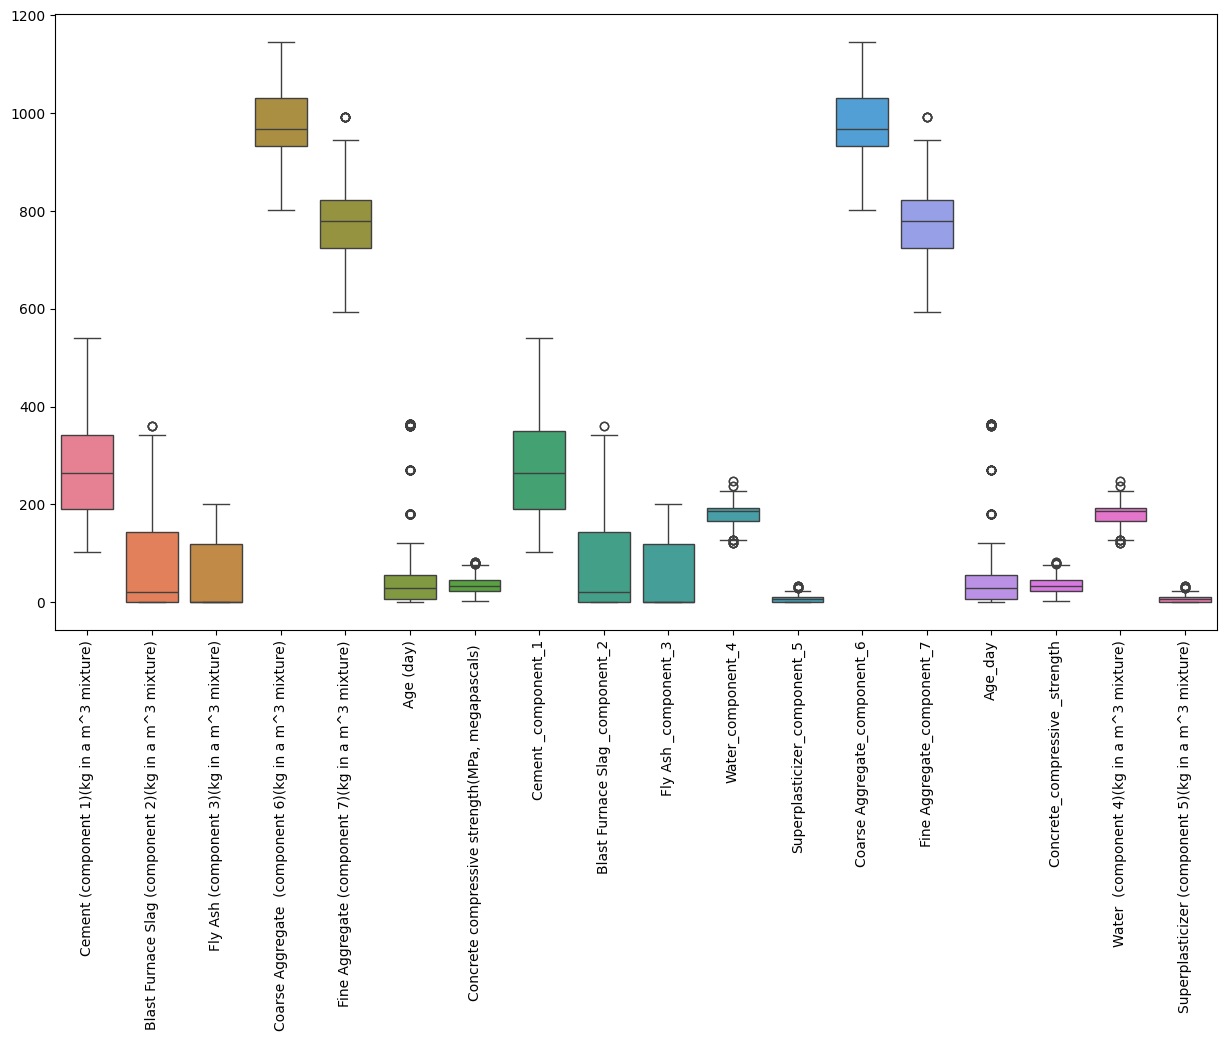

In [31]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [30]:
df.skew().sort_values(ascending=False)

,0
Age_day,3.253974
Age (day),3.246736
Superplasticizer (component 5)(kg in a m^3 mixture),0.980604
Superplasticizer_component_5,0.980604
Blast Furnace Slag _component_2,0.855225
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0.850913
Cement (component 1)(kg in a m^3 mixture),0.567858
Cement _component_1,0.564959
Fly Ash _component_3,0.497231
Fly Ash (component 3)(kg in a m^3 mixture),0.494390


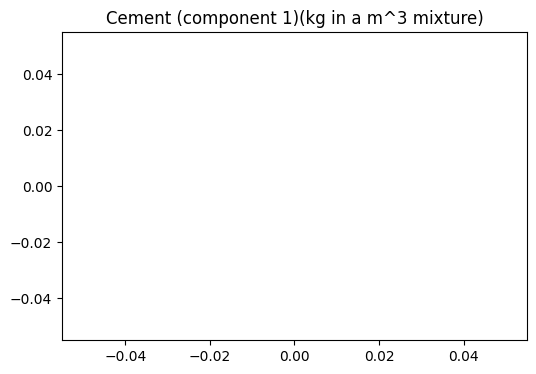

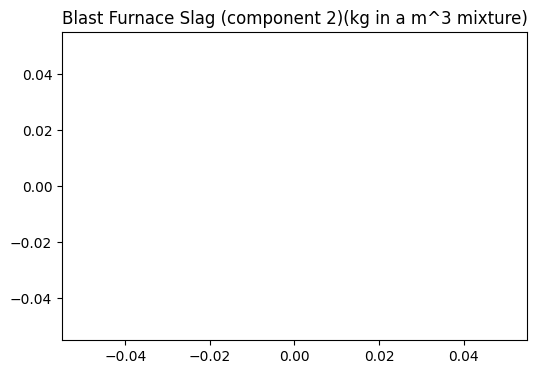

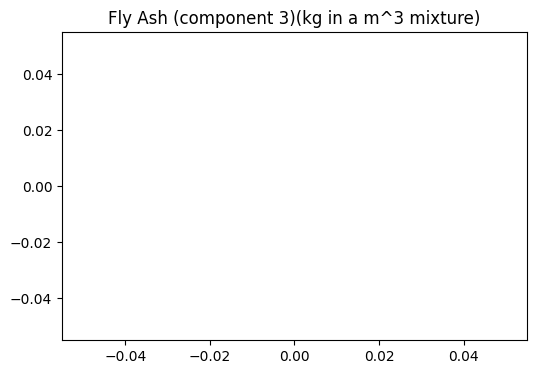

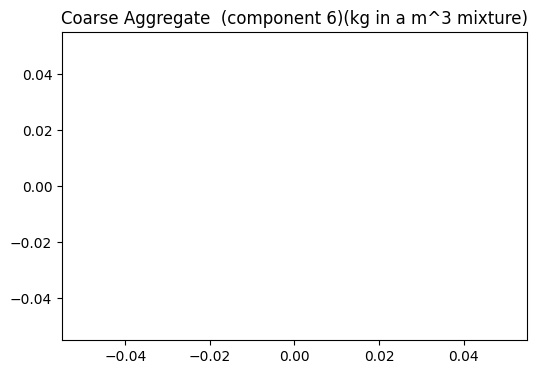

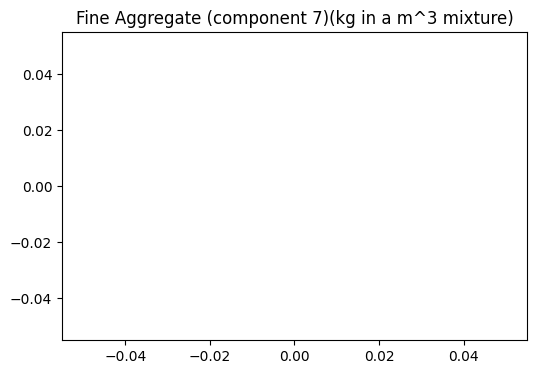

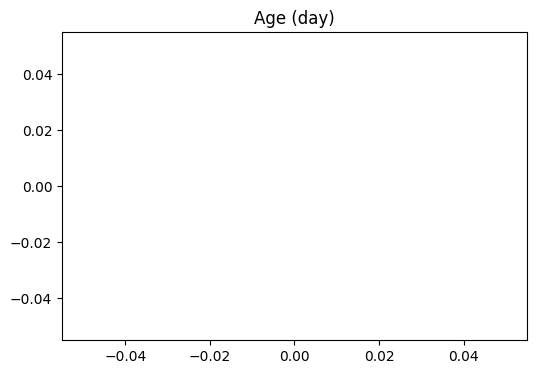

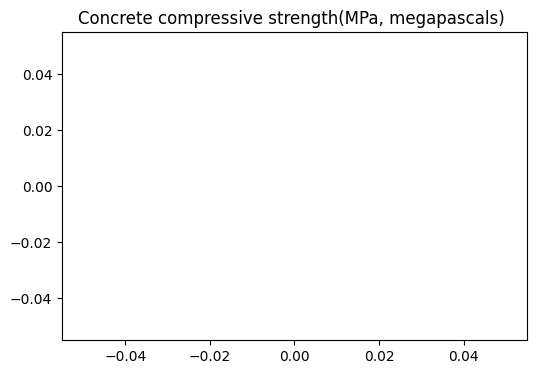

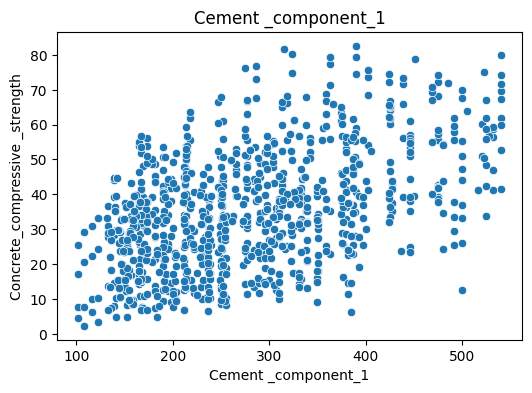

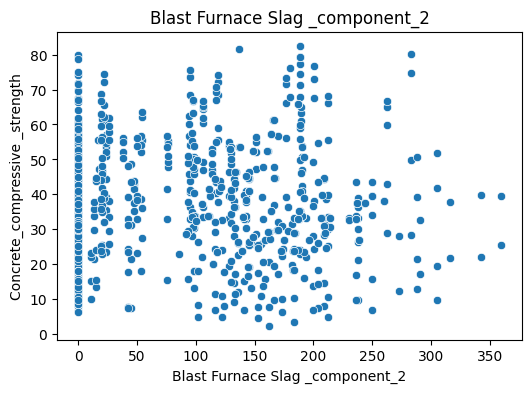

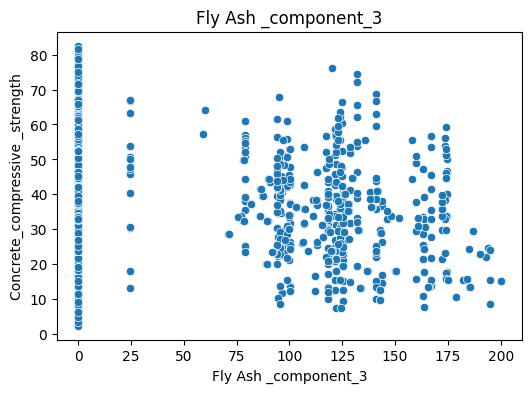

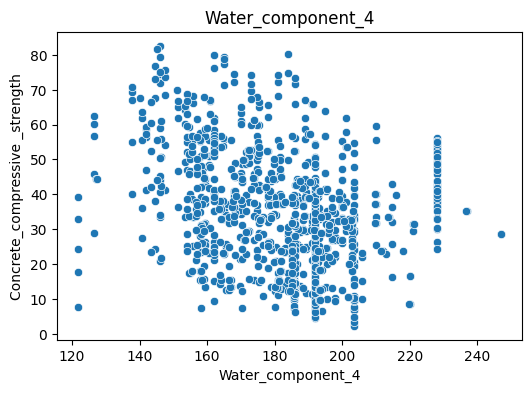

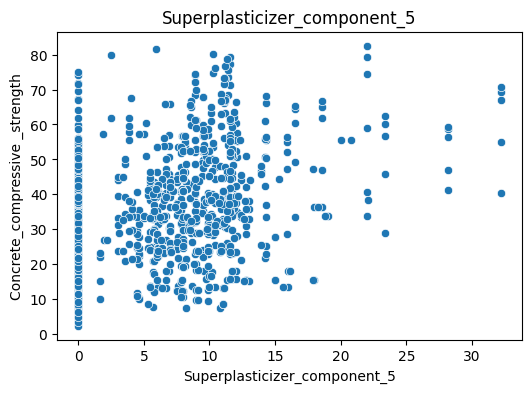

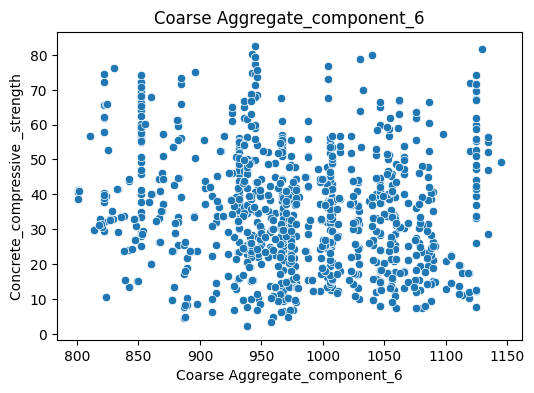

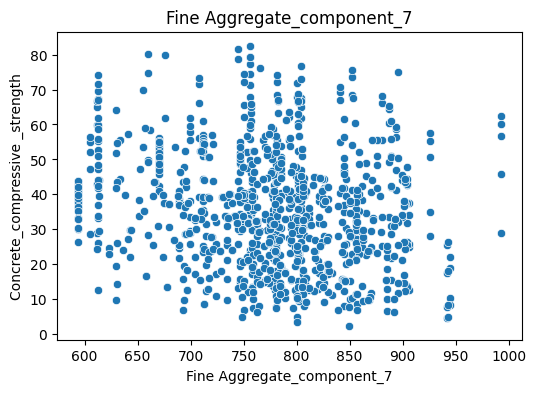

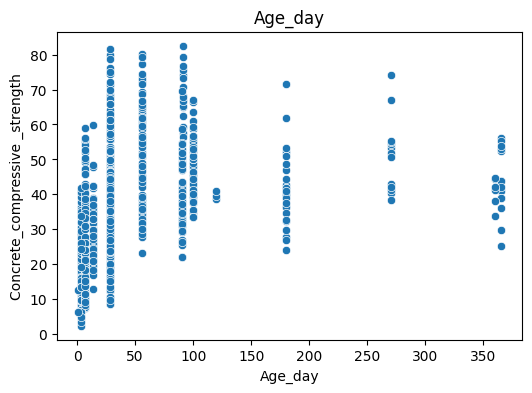

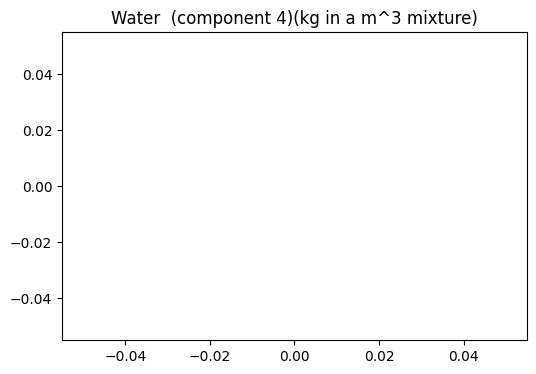

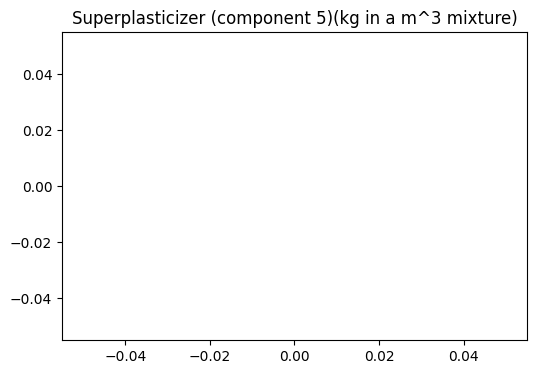

In [29]:
target = 'Concrete_compressive _strength'

for col in df.columns:

    if col != target:

        plt.figure(figsize=(6,4))

        sns.scatterplot(
            x=df[col],
            y=df[target]
        )

        plt.title(col)

        plt.show()

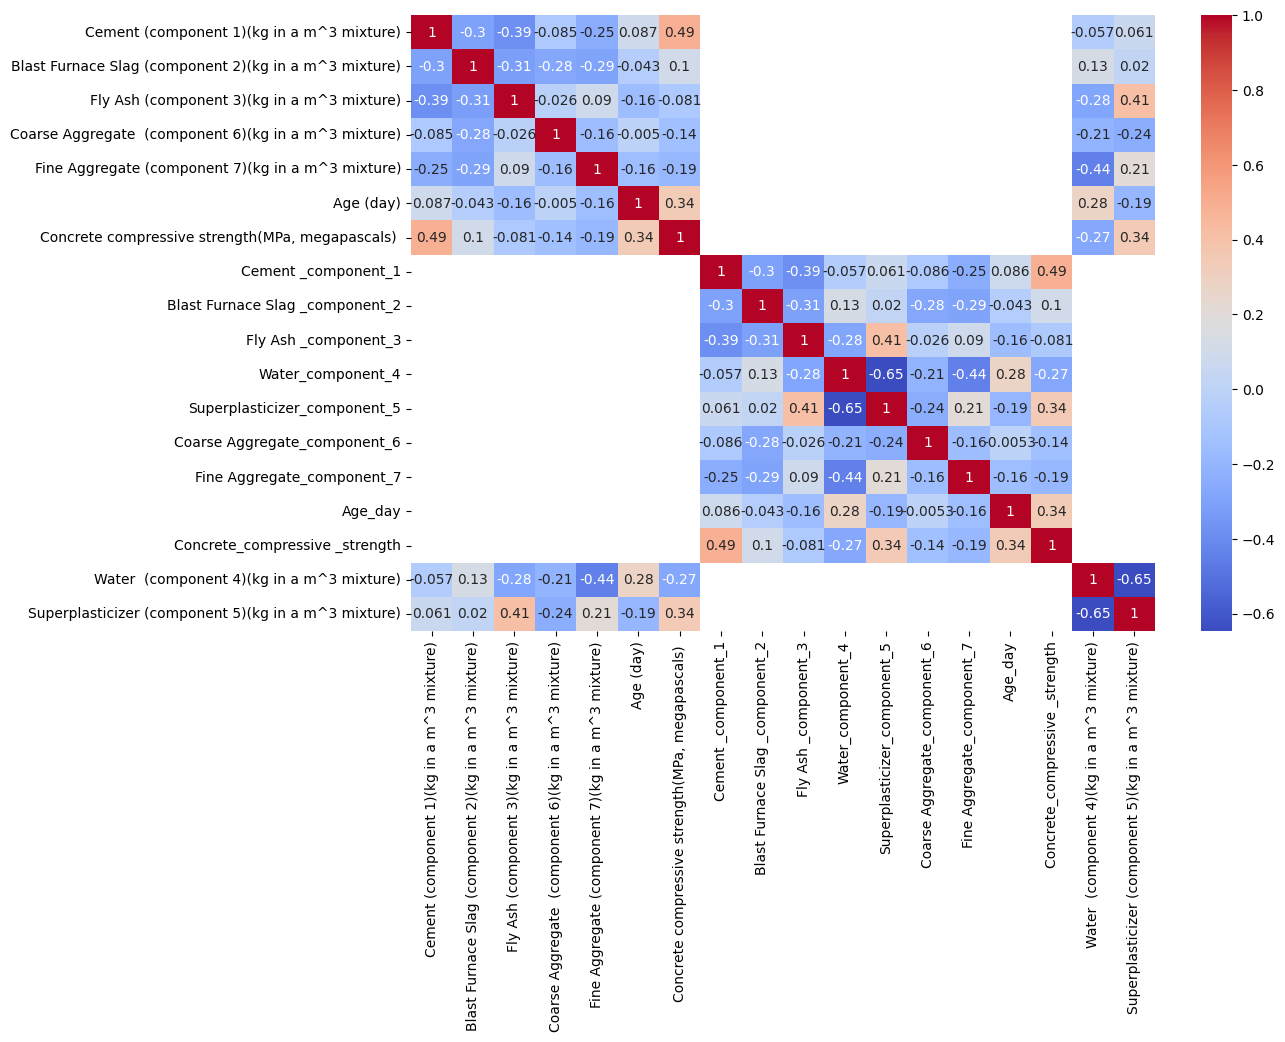

In [28]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [37]:
df.skew()

,0
Cement (component 1)(kg in a m^3 mixture),0.567858
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0.850913
Fly Ash (component 3)(kg in a m^3 mixture),0.494390
Coarse Aggregate (component 6)(kg in a m^3 mixture),-0.061857
Fine Aggregate (component 7)(kg in a m^3 mixture),-0.251747
Age (day),3.246736
"Concrete compressive strength(MPa, megapascals)",0.395233
Cement _component_1,0.564959
Blast Furnace Slag _component_2,0.855225
Fly Ash _component_3,0.497231


## Lets move the feature engineering

In [38]:
df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) ',
       'Cement _component_1', 'Blast Furnace Slag _component_2',
       'Fly Ash _component_3', 'Water_component_4',
       'Superplasticizer_component_5', 'Coarse Aggregate_component_6',
       'Fine Aggregate_component_7', 'Age_day',
       'Concrete_compressive _strength',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)'],
      dtype='object')

In [39]:
X = df.drop('Concrete_compressive _strength', axis=1)
y = df['Concrete_compressive _strength']

In [40]:
X.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),1005
Blast Furnace Slag (component 2)(kg in a m^3 mixture),1005
Fly Ash (component 3)(kg in a m^3 mixture),1005
Coarse Aggregate (component 6)(kg in a m^3 mixture),1005
Fine Aggregate (component 7)(kg in a m^3 mixture),1005
Age (day),1005
"Concrete compressive strength(MPa, megapascals)",1005
Cement _component_1,2005
Blast Furnace Slag _component_2,2005
Fly Ash _component_3,2005


In [41]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [42]:
# Log Transformation
import numpy as np

X_log = X.copy()

for col in X_log.columns:

    if (X_log[col] >= 0).all():
        X_log[col] = np.log1p(X_log[col])

X_log.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Cement _component_1,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture)
0,6.293419,0.000000,0.0,6.947937,6.517671,3.367296,4.394326,5.633472,4.291055,4.034883,5.209898,1.950647,6.882824,6.651169,3.847094,5.070998,1.734601
1,6.293419,0.000000,0.0,6.962243,6.517671,3.367296,4.141387,5.633472,4.291055,4.034883,5.209898,1.950647,6.882824,6.651169,3.847094,5.070998,1.734601
2,5.809643,4.966335,0.0,6.838405,6.388561,5.602119,3.720136,5.633472,4.291055,4.034883,5.209898,1.950647,6.882824,6.651169,3.847094,5.433722,0.000000
3,5.809643,4.966335,0.0,6.838405,6.388561,5.902633,3.738859,5.633472,4.291055,4.034883,5.209898,1.950647,6.882824,6.651169,3.847094,5.433722,0.000000
4,5.296315,4.893352,0.0,6.886940,6.717200,5.888878,3.813307,5.633472,4.291055,4.034883,5.209898,1.950647,6.882824,6.651169,3.847094,5.273000,0.000000


Train Test Split


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
print(X_train.shape)
print(X_test.shape)

(2408, 17)
(602, 17)


## Feature Scalling

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [50]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [48]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

## Apply Linearr Regression

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R2 Score :", r2_lr)
print("MAE      :", mae_lr)
print("RMSE     :", rmse_lr)

ValueError: Input y contains NaN.

In [55]:
print(y.isnull().sum())

2005


In [56]:
y[y.isnull()]

,Concrete_compressive _strength
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3085,NaN
3086,NaN
3087,NaN
3088,NaN


In [57]:
target_col = 'Concrete_compressive _strength'  # use your exact column name

print(df[target_col].isnull().sum())

2005


In [58]:
target_col = 'Concrete_compressive _strength'

df = df.dropna(subset=[target_col])

print(df[target_col].isnull().sum())

0


In [59]:
X = df.drop(target_col, axis=1)
y = df[target_col]

In [60]:
print("X NaN:", X.isnull().sum().sum())
print("y NaN:", y.isnull().sum())

X NaN: 9045
y NaN: 0


In [61]:
print(df.shape)

(1005, 18)


In [62]:
print("y_train NaN:", y_train.isnull().sum())
print("y_test NaN:", y_test.isnull().sum())

y_train NaN: 1579
y_test NaN: 426


In [63]:
import numpy as np

print("X_train_scaled NaN:", np.isnan(X_train_scaled).sum())
print("X_test_scaled NaN:", np.isnan(X_test_scaled).sum())

X_train_scaled NaN: 0
X_test_scaled NaN: 0


In [64]:
print(X.min())

Cement (component 1)(kg in a m^3 mixture)                  NaN
Blast Furnace Slag (component 2)(kg in a m^3 mixture)      NaN
Fly Ash (component 3)(kg in a m^3 mixture)                 NaN
Coarse Aggregate  (component 6)(kg in a m^3 mixture)       NaN
Fine Aggregate (component 7)(kg in a m^3 mixture)          NaN
Age (day)                                                  NaN
Concrete compressive strength(MPa, megapascals)            NaN
Cement _component_1                                      102.0
Blast Furnace Slag _component_2                            0.0
Fly Ash _component_3                                       0.0
Water_component_4                                        121.8
Superplasticizer_component_5                               0.0
Coarse Aggregate_component_6                             801.0
Fine Aggregate_component_7                               594.0
Age_day                                                    1.0
Water  (component 4)(kg in a m^3 mixture)              

In [65]:
print(X_log.isnull().sum())

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
Cement _component_1                                      0
Blast Furnace Slag _component_2                          0
Fly Ash _component_3                                     0
Water_component_4                                        0
Superplasticizer_component_5                             0
Coarse Aggregate_component_6                             0
Fine Aggregate_component_7                               0
Age_day                                                  0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)     

In [66]:
print("X_train NaN:", X_train_scaled.isnull().sum().sum())
print("X_test NaN:", X_test_scaled.isnull().sum().sum())
print("y_train NaN:", y_train.isnull().sum())
print("y_test NaN:", y_test.isnull().sum())

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [67]:
print(df.columns.tolist())

['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ', 'Cement _component_1', 'Blast Furnace Slag _component_2', 'Fly Ash _component_3', 'Water_component_4', 'Superplasticizer_component_5', 'Coarse Aggregate_component_6', 'Fine Aggregate_component_7', 'Age_day', 'Concrete_compressive _strength', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)']


In [68]:
target_col = 'Concrete_compressive _strength'   # your current target

print(df[target_col].head())
print(df[target_col].isnull().sum())

1030    79.99
1031    61.89
1032    40.27
1033    41.05
1034    44.30
Name: Concrete_compressive _strength, dtype: float64
0


In [69]:
df[df[target_col].isnull()].head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)",Cement _component_1,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Concrete_compressive _strength,Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture)


In [70]:
df = df.dropna(subset=[target_col])

print(df.shape)
print(df[target_col].isnull().sum())

(1005, 18)
0


In [71]:
X = df.drop(target_col, axis=1)
y = df[target_col]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
print("y_train NaN:", y_train.isnull().sum())
print("y_test NaN:", y_test.isnull().sum())

y_train NaN: 0
y_test NaN: 0


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [76]:
print("y_train NaN:", y_train.isnull().sum())
print("y_test NaN:", y_test.isnull().sum())

y_train NaN: 0
y_test NaN: 0


In [77]:
X_train.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),804
Blast Furnace Slag (component 2)(kg in a m^3 mixture),804
Fly Ash (component 3)(kg in a m^3 mixture),804
Coarse Aggregate (component 6)(kg in a m^3 mixture),804
Fine Aggregate (component 7)(kg in a m^3 mixture),804
Age (day),804
"Concrete compressive strength(MPa, megapascals)",804
Cement _component_1,0
Blast Furnace Slag _component_2,0
Fly Ash _component_3,0


In [78]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

,0
Cement (component 1)(kg in a m^3 mixture),804
Blast Furnace Slag (component 2)(kg in a m^3 mixture),804
Fly Ash (component 3)(kg in a m^3 mixture),804
Coarse Aggregate (component 6)(kg in a m^3 mixture),804
Fine Aggregate (component 7)(kg in a m^3 mixture),804
Age (day),804
"Concrete compressive strength(MPa, megapascals)",804
Water (component 4)(kg in a m^3 mixture),804
Superplasticizer (component 5)(kg in a m^3 mixture),804


In [79]:
print("X_train NaN:", X_train.isnull().sum().sum())
print("X_test NaN:", X_test.isnull().sum().sum())

X_train NaN: 7236
X_test NaN: 1809


In [80]:
from sklearn.impute import KNNImputer
import pandas as pd

imputer = KNNImputer(n_neighbors=3)

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

ValueError: Shape of passed values is (804, 8), indices imply (804, 17)

In [81]:
print(X_train.shape)

print(X_train.dtypes)

print(X_train.columns)

(804, 17)
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                float64
Concrete compressive strength(MPa, megapascals)          float64
Cement _component_1                                      float64
Blast Furnace Slag _component_2                          float64
Fly Ash _component_3                                     float64
Water_component_4                                        float64
Superplasticizer_component_5                             float64
Coarse Aggregate_component_6                             float64
Fine Aggregate_component_7                               float64
Age_day                                                  float64
Water  (compone

In [82]:
X_train.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),804
Blast Furnace Slag (component 2)(kg in a m^3 mixture),804
Fly Ash (component 3)(kg in a m^3 mixture),804
Coarse Aggregate (component 6)(kg in a m^3 mixture),804
Fine Aggregate (component 7)(kg in a m^3 mixture),804
Age (day),804
"Concrete compressive strength(MPa, megapascals)",804
Cement _component_1,0
Blast Furnace Slag _component_2,0
Fly Ash _component_3,0


In [83]:
all_null_cols = X_train.columns[X_train.isnull().all()]

print(all_null_cols)

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) ',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)'],
      dtype='object')


In [84]:
print(X_train.select_dtypes(exclude=['number']).columns)

Index([], dtype='object')


In [85]:
print(X_train.columns)

print(X_train.select_dtypes(exclude=['number']).columns)

print(X_train.isnull().sum())

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) ',
       'Cement _component_1', 'Blast Furnace Slag _component_2',
       'Fly Ash _component_3', 'Water_component_4',
       'Superplasticizer_component_5', 'Coarse Aggregate_component_6',
       'Fine Aggregate_component_7', 'Age_day',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)'],
      dtype='object')
Index([], dtype='object')
Cement (component 1)(kg in a m^3 mixture)                804
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    804
Fly Ash (component 3)(kg in a m^3 mixture)               804
Coarse Aggregate  (component 6)(kg in a m^3 mixture)  

In [86]:
cols_to_drop = [
    'Cement (component 1)(kg in a m^3 mixture)',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
    'Fly Ash (component 3)(kg in a m^3 mixture)',
    'Water  (component 4)(kg in a m^3 mixture)',
    'Superplasticizer (component 5)(kg in a m^3 mixture)',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)',
    'Age (day)',
    'Concrete compressive strength(MPa, megapascals) '
]

X = X.drop(columns=cols_to_drop, errors='ignore')

In [87]:
print(X.shape)
print(X.isnull().sum().sum())

(1005, 8)
0


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## this is Linear regression Model

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.5801703029028777


Random forest Model

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred_rf))
print("MAE      :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE     :", np.sqrt(np.mean((y_test - y_pred_rf)**2)))

R2 Score : 0.9092429938430198
MAE      : 3.532899735844591
RMSE     : 5.203371392190019


In [92]:
import joblib

joblib.dump(rf, "cement_strength_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [93]:
import os

os.listdir()

['.config',
 'Training_Batch_Files (1).zip',
 'Training_Batch_Files.zip',
 'cement_strength_model.pkl',
 'Training_Batch_Files (2).zip',
 'dataset',
 'scaler.pkl',
 'sample_data']

In [94]:
from google.colab import files

files.download("cement_strength_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>